In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from anilos import *
from classy import Class
from healpy.newvisufunc import projview
from scipy.sparse import coo_matrix
import healpy as hp
import time 

In [2]:
# Relative difference between alms
def relative_difference (alm, blm):
    a = alm
    b = blm
    return 100 * np.abs((a - b) / a)


In [3]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 18,
    "font.size": 18,
    "legend.fontsize": 12,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
})

# Error plots

In [4]:
# Cosmological parameters
Omega_b = 0.04897
Omega_cdm = 0.2606
Omega_K = 1e-5
Omega_Lambda = 1 - Omega_b - Omega_cdm - Omega_K
# Set homogeneous scale
sqrth = 0.0008
z_reio = 7.67
# Parameter dictionary for anilos
params = {'Omega_K': Omega_K,
          'Omega_b': Omega_b,
          'Omega_cdm': Omega_cdm,
          'Omega_Lambda':Omega_Lambda,
          'z_reio': z_reio,
          'sqrth': sqrth}

In [5]:
# Setting the parameters
ell_max = 100 # maximum multipole for the los
x = Anilos(params)
# Solve the perturbations
x.tensor_solver()
x.vector_solver()
x.alm_tensor(ell_max, healpy=False)
x.alm_vector(ell_max, healpy=False)

In [6]:
# Get the alms
almT_tensor_anilos = x.almT_tensor
almE_tensor_anilos = x.almE_tensor
almB_tensor_anilos = x.almB_tensor

# For vector modes, AniLoS computes the alms from the dipole,
# but AniCLASS computes only from the quadrupole
almT_vector_anilos = x.almT_vector[1:]
almE_vector_anilos = x.almE_vector[1:]
almB_vector_anilos = x.almB_vector[1:]

In [7]:
# Get the perturbations from the Boltzmann hierarchy in AniLoS
# Note the order: beta: 0, beta': 1, N2: 2, T2: 3, E2: 4, B2: 5, N3: 6, T3: 7, E3: 8, B3: 9, ...
boltzmann = x.nteb_tensor

pertT2_anilos_tensor = boltzmann[3][-1]
pertT3_anilos_tensor = boltzmann[7][-1]
pertT4_anilos_tensor = boltzmann[11][-1]
pertT5_anilos_tensor = boltzmann[15][-1]
pertT6_anilos_tensor = boltzmann[19][-1]

pertE2_anilos_tensor = boltzmann[4][-1]
pertE3_anilos_tensor = boltzmann[8][-1]
pertE4_anilos_tensor = boltzmann[12][-1]
pertE5_anilos_tensor = boltzmann[16][-1]
pertE6_anilos_tensor = boltzmann[20][-1]

pertB2_anilos_tensor = boltzmann[5][-1]
pertB3_anilos_tensor = boltzmann[9][-1]
pertB4_anilos_tensor = boltzmann[13][-1]
pertB5_anilos_tensor = boltzmann[17][-1]
pertB6_anilos_tensor = boltzmann[21][-1]

In [8]:
# Note the order: phi: 0, vb: 1, N1: 2, T1: 3, E1: 4, B1: 5, N2: 6, T2: 7, E2: 8, B2: 9, ...
boltzmann = x.nteb_vector

pertT2_anilos_vector = boltzmann[7][-1]
pertT3_anilos_vector = boltzmann[11][-1]
pertT4_anilos_vector = boltzmann[15][-1]
pertT5_anilos_vector = boltzmann[19][-1]
pertT6_anilos_vector = boltzmann[23][-1]

pertE2_anilos_vector = boltzmann[8][-1]
pertE3_anilos_vector = boltzmann[12][-1]
pertE4_anilos_vector = boltzmann[16][-1]
pertE5_anilos_vector = boltzmann[20][-1]
pertE6_anilos_vector = boltzmann[24][-1]

pertB2_anilos_vector = boltzmann[9][-1]
pertB3_anilos_vector = boltzmann[13][-1]
pertB4_anilos_vector = boltzmann[17][-1]
pertB5_anilos_vector = boltzmann[21][-1]
pertB6_anilos_vector = boltzmann[25][-1]


In [9]:
# Now AniCLASS
k_output_tensor = 2 / x.spiraling_length
k_output_vector = 1 / x.spiraling_length
k_output_str = f'{k_output_tensor}, {k_output_vector}'
cosmo = Class()
params = {'Omega_k': Omega_K,
          'Omega_b': Omega_b,
          'Omega_cdm': Omega_cdm,
          'Omega_Lambda': Omega_Lambda,
          'z_reio' : z_reio,

          'hierarchy': 'tam',
          'statistics': 'non_stochastic',
          'non_stochastic_type': 'bianchi',

          'output': 'tCl pCl',
          'modes': 't v',
          'non_stochastic_format': 'healpix_alm',
          'multipole_normalization': 'observable',
          'k_output_values': k_output_str,
          'l_max_tensors': ell_max,
          'l_max_vectors': ell_max,

          'tight_coupling_trigger_tau_c_over_tau_h':0.005,
          'start_small_omega_tau': 0.005,
          'perturbations_sampling_stepsize' : 0.01,
          'tol_perturbations_integration' : 1e-6,
          'radiation_streaming_approximation': 3,
          'hyper_x_min' : 1e-7,
          'l_max_g': 30,
          'l_max_pol_g': 30,
          'l_max_ur': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'l_max_g_vec': 30,
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,

          'background_verbose': 1
         }
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 8.940937e-04 corresponds to sqrth = 1.600000e-03 for tensor modes and 8.000000e-04 for vector modes
k_output_values[1] = 1.788187e-03 corresponds to sqrth = 8.000000e-04 for tensor modes and 4.000000e-04 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.774461 Gyr
 -> conformal age = 14157.521193 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3402.309622
    corresponding to conformal time = 112.836889 Mpc


In [10]:
# Get the alms from AniCLASS
alm_tensor_class = cosmo.alm(ell_max)['k_1']['t']

# Compute the normalization to compare with AniLoS
almT_tensor_class = alm_tensor_class['T']
almE_tensor_class = alm_tensor_class['E']
almB_tensor_class = alm_tensor_class['B']

In [11]:
# Get the alms from AniCLASS
alm_vector_class = cosmo.alm(ell_max)['k_0']['v']

# Compute the normalization to compare with AniLoS
almT_vector_class = alm_vector_class['T']
almE_vector_class = alm_vector_class['E']
almB_vector_class = alm_vector_class['B']

In [12]:
# Get the perturbations from the Boltzmann hierarchy
perturbations_class = cosmo.get_perturbations()
perturbations_tensor_class = perturbations_class['tensor'][1]
perturbations_vector_class = perturbations_class['vector'][0]
perturbations_T2_tensor = perturbations_tensor_class['Re@Theta_2'][-1] + 1j * perturbations_tensor_class['Im@Theta_2'][-1]
perturbations_T3_tensor = perturbations_tensor_class['Re@T_3'][-1] + 1j * perturbations_tensor_class['Im@T_3'][-1]
perturbations_T4_tensor = perturbations_tensor_class['Re@T_4'][-1] + 1j * perturbations_tensor_class['Im@T_4'][-1]
perturbations_T5_tensor = perturbations_tensor_class['Re@T_5'][-1] + 1j * perturbations_tensor_class['Im@T_5'][-1]
perturbations_T6_tensor = perturbations_tensor_class['Re@T_6'][-1] + 1j * perturbations_tensor_class['Im@T_6'][-1]

perturbations_E2_tensor = perturbations_tensor_class['Re@E_2'][-1] + 1j * perturbations_tensor_class['Im@E_2'][-1]
perturbations_E3_tensor = perturbations_tensor_class['Re@E_3'][-1] + 1j * perturbations_tensor_class['Im@E_3'][-1]
perturbations_E4_tensor = perturbations_tensor_class['Re@E_4'][-1] + 1j * perturbations_tensor_class['Im@E_4'][-1]
perturbations_E5_tensor = perturbations_tensor_class['Re@E_5'][-1] + 1j * perturbations_tensor_class['Im@E_5'][-1]
perturbations_E6_tensor = perturbations_tensor_class['Re@E_6'][-1] + 1j * perturbations_tensor_class['Im@E_6'][-1]

perturbations_B2_tensor = perturbations_tensor_class['Re@B_2'][-1] + 1j * perturbations_tensor_class['Im@B_2'][-1]
perturbations_B3_tensor = perturbations_tensor_class['Re@B_3'][-1] + 1j * perturbations_tensor_class['Im@B_3'][-1]
perturbations_B4_tensor = perturbations_tensor_class['Re@B_4'][-1] + 1j * perturbations_tensor_class['Im@B_4'][-1]
perturbations_B5_tensor = perturbations_tensor_class['Re@B_5'][-1] + 1j * perturbations_tensor_class['Im@B_5'][-1]
perturbations_B6_tensor = perturbations_tensor_class['Re@B_6'][-1] + 1j * perturbations_tensor_class['Im@B_6'][-1]

In [13]:
perturbations_T2_vector = perturbations_vector_class['Re@T_2'][-1] + 1j * perturbations_vector_class['Im@T_2'][-1]
perturbations_T3_vector = perturbations_vector_class['Re@T_3'][-1] + 1j * perturbations_vector_class['Im@T_3'][-1]
perturbations_T4_vector = perturbations_vector_class['Re@T_4'][-1] + 1j * perturbations_vector_class['Im@T_4'][-1]
perturbations_T5_vector = perturbations_vector_class['Re@T_5'][-1] + 1j * perturbations_vector_class['Im@T_5'][-1]
perturbations_T6_vector = perturbations_vector_class['Re@T_6'][-1] + 1j * perturbations_vector_class['Im@T_6'][-1]

perturbations_E2_vector = perturbations_vector_class['Re@E_2'][-1] + 1j * perturbations_vector_class['Im@E_2'][-1]
perturbations_E3_vector = perturbations_vector_class['Re@E_3'][-1] + 1j * perturbations_vector_class['Im@E_3'][-1]
perturbations_E4_vector = perturbations_vector_class['Re@E_4'][-1] + 1j * perturbations_vector_class['Im@E_4'][-1]
perturbations_E5_vector = perturbations_vector_class['Re@E_5'][-1] + 1j * perturbations_vector_class['Im@E_5'][-1]
perturbations_E6_vector = perturbations_vector_class['Re@E_6'][-1] + 1j * perturbations_vector_class['Im@E_6'][-1]

perturbations_B2_vector = perturbations_vector_class['Re@B_2'][-1] + 1j * perturbations_vector_class['Im@B_2'][-1]
perturbations_B3_vector = perturbations_vector_class['Re@B_3'][-1] + 1j * perturbations_vector_class['Im@B_3'][-1]
perturbations_B4_vector = perturbations_vector_class['Re@B_4'][-1] + 1j * perturbations_vector_class['Im@B_4'][-1]
perturbations_B5_vector = perturbations_vector_class['Re@B_5'][-1] + 1j * perturbations_vector_class['Im@B_5'][-1]
perturbations_B6_vector = perturbations_vector_class['Re@B_6'][-1] + 1j * perturbations_vector_class['Im@B_6'][-1]

In [14]:
# Compute relative differences (in percent)
almT_tensor_reldiff = relative_difference(almT_tensor_anilos, almT_tensor_class)
almE_tensor_reldiff = relative_difference(almE_tensor_anilos, almE_tensor_class)
almB_tensor_reldiff = relative_difference(almB_tensor_anilos, almB_tensor_class)

almT_vector_reldiff = relative_difference(almT_vector_anilos, almT_vector_class)
almE_vector_reldiff = relative_difference(almE_vector_anilos, almE_vector_class)
almB_vector_reldiff = relative_difference(almB_vector_anilos, almB_vector_class)


In [15]:
diff_anilos_aniclassT2_tensor = np.abs((pertT2_anilos_tensor - perturbations_T2_tensor) / perturbations_T2_tensor)
diff_anilos_aniclassT3_tensor = np.abs((pertT3_anilos_tensor - perturbations_T3_tensor) / perturbations_T3_tensor)
diff_anilos_aniclassT4_tensor = np.abs((pertT4_anilos_tensor - perturbations_T4_tensor) / perturbations_T4_tensor)
diff_anilos_aniclassT5_tensor = np.abs((pertT5_anilos_tensor - perturbations_T5_tensor) / perturbations_T5_tensor)
diff_anilos_aniclassT6_tensor = np.abs((pertT6_anilos_tensor - perturbations_T6_tensor) / perturbations_T6_tensor)

diff_anilos_aniclassE2_tensor = np.abs((pertE2_anilos_tensor - perturbations_E2_tensor) / perturbations_E2_tensor)
diff_anilos_aniclassE3_tensor = np.abs((pertE3_anilos_tensor - perturbations_E3_tensor) / perturbations_E3_tensor)
diff_anilos_aniclassE4_tensor = np.abs((pertE4_anilos_tensor - perturbations_E4_tensor) / perturbations_E4_tensor)
diff_anilos_aniclassE5_tensor = np.abs((pertE5_anilos_tensor - perturbations_E5_tensor) / perturbations_E5_tensor)
diff_anilos_aniclassE6_tensor = np.abs((pertE6_anilos_tensor - perturbations_E6_tensor) / perturbations_E6_tensor)

diff_anilos_aniclassB2_tensor = np.abs((pertB2_anilos_tensor - perturbations_B2_tensor) / perturbations_B2_tensor)
diff_anilos_aniclassB3_tensor = np.abs((pertB3_anilos_tensor - perturbations_B3_tensor) / perturbations_B3_tensor)
diff_anilos_aniclassB4_tensor = np.abs((pertB4_anilos_tensor - perturbations_B4_tensor) / perturbations_B4_tensor)
diff_anilos_aniclassB5_tensor = np.abs((pertB5_anilos_tensor - perturbations_B5_tensor) / perturbations_B5_tensor)
diff_anilos_aniclassB6_tensor = np.abs((pertB6_anilos_tensor - perturbations_B6_tensor) / perturbations_B6_tensor)

In [16]:
diff_anilos_aniclassT2_vector = np.abs((pertT2_anilos_vector - perturbations_T2_vector) / perturbations_T2_vector)
diff_anilos_aniclassT3_vector = np.abs((pertT3_anilos_vector - perturbations_T3_vector) / perturbations_T3_vector)
diff_anilos_aniclassT4_vector = np.abs((pertT4_anilos_vector - perturbations_T4_vector) / perturbations_T4_vector)
diff_anilos_aniclassT5_vector = np.abs((pertT5_anilos_vector - perturbations_T5_vector) / perturbations_T5_vector)
diff_anilos_aniclassT6_vector = np.abs((pertT6_anilos_vector - perturbations_T6_vector) / perturbations_T6_vector)

diff_anilos_aniclassE2_vector = np.abs((pertE2_anilos_vector - perturbations_E2_vector) / perturbations_E2_vector)
diff_anilos_aniclassE3_vector = np.abs((pertE3_anilos_vector - perturbations_E3_vector) / perturbations_E3_vector)
diff_anilos_aniclassE4_vector = np.abs((pertE4_anilos_vector - perturbations_E4_vector) / perturbations_E4_vector)
diff_anilos_aniclassE5_vector = np.abs((pertE5_anilos_vector - perturbations_E5_vector) / perturbations_E5_vector)
diff_anilos_aniclassE6_vector = np.abs((pertE6_anilos_vector - perturbations_E6_vector) / perturbations_E6_vector)

diff_anilos_aniclassB2_vector = np.abs((pertB2_anilos_vector - perturbations_B2_vector) / perturbations_B2_vector)
diff_anilos_aniclassB3_vector = np.abs((pertB3_anilos_vector - perturbations_B3_vector) / perturbations_B3_vector)
diff_anilos_aniclassB4_vector = np.abs((pertB4_anilos_vector - perturbations_B4_vector) / perturbations_B4_vector)
diff_anilos_aniclassB5_vector = np.abs((pertB5_anilos_vector - perturbations_B5_vector) / perturbations_B5_vector)
diff_anilos_aniclassB6_vector = np.abs((pertB6_anilos_vector - perturbations_B6_vector) / perturbations_B6_vector)

In [17]:
plot_compar_anilos_aniclassT_tensor = 100 * np.array([diff_anilos_aniclassT2_tensor, diff_anilos_aniclassT3_tensor, diff_anilos_aniclassT4_tensor, diff_anilos_aniclassT5_tensor, diff_anilos_aniclassT6_tensor])
plot_compar_anilos_aniclassE_tensor = 100 * np.array([diff_anilos_aniclassE2_tensor, diff_anilos_aniclassE3_tensor, diff_anilos_aniclassE4_tensor, diff_anilos_aniclassE5_tensor, diff_anilos_aniclassE6_tensor])
plot_compar_anilos_aniclassB_tensor = 100 * np.array([diff_anilos_aniclassB2_tensor, diff_anilos_aniclassB3_tensor, diff_anilos_aniclassB4_tensor, diff_anilos_aniclassB5_tensor, diff_anilos_aniclassB6_tensor])

plot_compar_anilos_aniclassT_vector = 100 * np.array([diff_anilos_aniclassT2_vector, diff_anilos_aniclassT3_vector, diff_anilos_aniclassT4_vector, diff_anilos_aniclassT5_vector, diff_anilos_aniclassT6_vector])
plot_compar_anilos_aniclassE_vector = 100 * np.array([diff_anilos_aniclassE2_vector, diff_anilos_aniclassE3_vector, diff_anilos_aniclassE4_vector, diff_anilos_aniclassE5_vector, diff_anilos_aniclassE6_vector])
plot_compar_anilos_aniclassB_vector = 100 * np.array([diff_anilos_aniclassB2_vector, diff_anilos_aniclassB3_vector, diff_anilos_aniclassB4_vector, diff_anilos_aniclassB5_vector, diff_anilos_aniclassB6_vector])

In [18]:
# Array of ells for plot
ell_array = np.linspace(2, ell_max, ell_max-1)
ell_array_hie = np.array([2, 3, 4, 5, 6])

Text(0.5, 0, '$\\ell$')

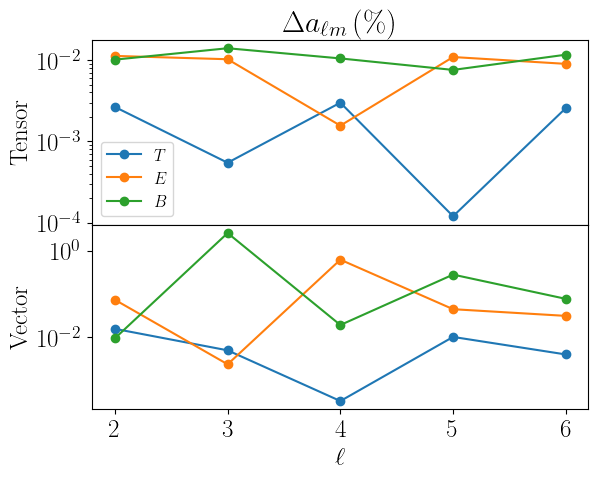

In [19]:
fig, axs = plt.subplots(2, 1, sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace=0)

# Plot each graph
axs[0].plot(ell_array_hie, plot_compar_anilos_aniclassT_tensor, marker='o', label=r'$T$')
axs[0].plot(ell_array_hie, plot_compar_anilos_aniclassE_tensor, marker='o', label=r'$E$')
axs[0].plot(ell_array_hie, plot_compar_anilos_aniclassB_tensor, marker='o', label=r'$B$')
axs[0].set_yscale('log')
axs[0].set_ylabel(r'Tensor')
axs[0].legend()
axs[0].set_title(r'$\Delta a_{\ell m}\,(\%)$')
#axs[0].set_ylim(2e-4, 2)

axs[1].plot(ell_array_hie, plot_compar_anilos_aniclassT_vector, marker='o')
axs[1].plot(ell_array_hie, plot_compar_anilos_aniclassE_vector, marker='o')
axs[1].plot(ell_array_hie, plot_compar_anilos_aniclassB_vector, marker='o')
axs[1].set_yscale('log')
axs[1].set_ylabel(r'Vector')
#axs[1].set_ylabel(r'$\Delta a_{\ell m}^{E}$\,(\%)', fontsize=14)

#axs[2].plot(ell, delta_alm_T, marker='o', color='blue')
#axs[2].set_yscale('log')
#axs[2].set_ylabel(r'$\Delta a_{\ell m}^{B}$\,(\%)', fontsize=14)
axs[1].set_xlabel(r'$\ell$')

#plt.savefig('alm_delta_boltzmann2.pdf', bbox_inches='tight')

Text(0.5, 0, '$\\ell$')

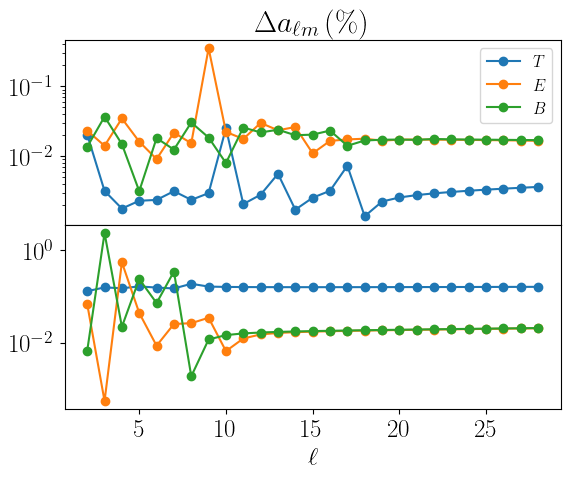

In [20]:
fig, axs = plt.subplots(2, 1, sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace=0)

# Plot each graph
axs[0].plot(ell_array[:27], almT_tensor_reldiff[:27], marker='o', label=r'$T$')
axs[0].plot(ell_array[:27], almE_tensor_reldiff[:27], marker='o', label=r'$E$')
axs[0].plot(ell_array[:27], almB_tensor_reldiff[:27], marker='o', label=r'$B$')
axs[0].set_yscale('log')
#axs[0].set_ylabel(r'Tensor', fontsize=15)
axs[0].legend()
axs[0].set_title(r'$\Delta a_{\ell m}\,(\%)$')
#axs[0].set_ylim(2e-4, 2)

axs[1].plot(ell_array[:27], almT_vector_reldiff[:27], marker='o')
axs[1].plot(ell_array[:27], almE_vector_reldiff[:27], marker='o')
axs[1].plot(ell_array[:27], almB_vector_reldiff[:27], marker='o')
axs[1].set_yscale('log')
#axs[1].set_ylabel(r'Vector', fontsize=15)
#axs[1].set_ylabel(r'$\Delta a_{\ell m}^{E}$\,(\%)', fontsize=14)

#axs[2].plot(ell, delta_alm_T, marker='o', color='blue')
#axs[2].set_yscale('log')
#axs[2].set_ylabel(r'$\Delta a_{\ell m}^{B}$\,(\%)', fontsize=14)
axs[1].set_xlabel(r'$\ell$')

#plt.savefig('alm_delta_2.pdf', bbox_inches='tight')

Text(0.5, 0, '$\\ell$')

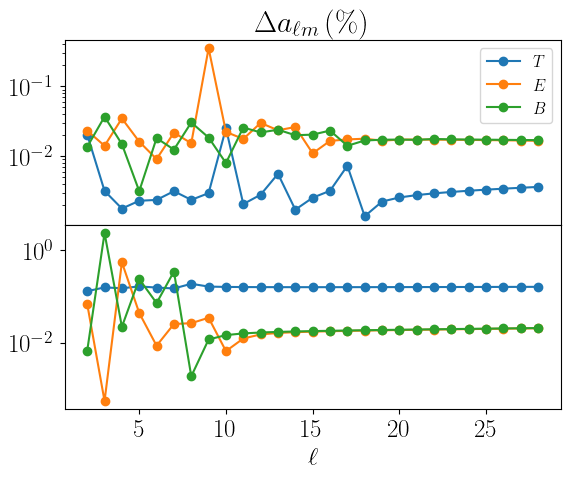

In [21]:
fig, axs = plt.subplots(2, 1, sharex=True, 
                        gridspec_kw={'height_ratios': [1, 1]})
fig.subplots_adjust(hspace=0)

# Plot each graph
axs[0].plot(ell_array[:27], almT_tensor_reldiff[:27], marker='o', label=r'$T$')
axs[0].plot(ell_array[:27], almE_tensor_reldiff[:27], marker='o', label=r'$E$')
axs[0].plot(ell_array[:27], almB_tensor_reldiff[:27], marker='o', label=r'$B$')
axs[0].set_yscale('log')
#axs[0].set_ylabel(r'Tensor', fontsize=15)
axs[0].legend()
axs[0].set_title(r'$\Delta a_{\ell m}\,(\%)$')
#axs[0].set_ylim(2e-4, 2)

axs[1].plot(ell_array[:27], almT_vector_reldiff[:27], marker='o')
axs[1].plot(ell_array[:27], almE_vector_reldiff[:27], marker='o')
axs[1].plot(ell_array[:27], almB_vector_reldiff[:27], marker='o')
axs[1].set_yscale('log')
#axs[1].set_ylabel(r'Vector', fontsize=15)
#axs[1].set_ylabel(r'$\Delta a_{\ell m}^{E}$\,(\%)', fontsize=14)

#axs[2].plot(ell, delta_alm_T, marker='o', color='blue')
#axs[2].set_yscale('log')
#axs[2].set_ylabel(r'$\Delta a_{\ell m}^{B}$\,(\%)', fontsize=14)
axs[1].set_xlabel(r'$\ell$')

#plt.savefig('alm_delta_2.pdf', bbox_inches='tight')

In [22]:
# Free memory
cosmo.struct_cleanup()

# Perturbations

## Tensor

In [23]:
Omega_K = 0.1
sqrth = 0.01
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [24]:
x.tensor_solver()
# Get the scale factor
scale_factor = x.atable

# Get the perturbations
boltzmann_tc = x.tensor_tc # Perturbations during tight coupling
boltzmann = x.nteb_tensor # Perturbations after tight coupling

beta = boltzmann[0] # Shear after tc
N2_viih_tensor = boltzmann[2] # Anisotropic stress after tc
beta_tc = boltzmann_tc[0] # Shear during tc
N2_tc = boltzmann_tc[2] # Anisotropic stress during tc
beta_viih_tensor = np.hstack((beta_tc, beta))
N_viih_tensor = np.hstack((N2_tc, N2_viih_tensor))
index_end_tc = x.index_end_tightc # Index of the end of tight coupling
scale_factor_after_tc_viih = scale_factor[index_end_tc:]

In [25]:
Omega_K = 1e-5
sqrth = 1e-3
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [26]:
x.tensor_solver()
index_end_tc = x.index_end_tightc
scale_factor_after_tc_vii0 = x.atable[index_end_tc:]
boltzmann_tc = x.tensor_tc
boltzmann = x.nteb_tensor
beta = boltzmann[0]
N2_vii0_tensor = boltzmann[2]

beta_tc = boltzmann_tc[0]
N2_tc = boltzmann_tc[2]
beta_vii0_tensor = np.hstack((beta_tc, beta))
N_vii0_tensor = np.hstack((N2_tc, N2_vii0_tensor))

In [27]:
Omega_K = 0.1
sqrth = 1e4
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [28]:
x.tensor_solver()
index_end_tc = x.index_end_tightc
scale_factor_after_tc_v = x.atable[index_end_tc:]
boltzmann_tc = x.tensor_tc
boltzmann = x.nteb_tensor
beta = boltzmann[0]
N2_v_tensor = boltzmann[2]

beta_tc = boltzmann_tc[0]
N2_tc = boltzmann_tc[2]
beta_v_tensor = np.hstack((beta_tc, beta))
N_v_tensor = np.hstack((N2_tc, N2_v_tensor))

In [29]:
Omega_K = -0.1
sqrth = 0.01
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [30]:
x.tensor_solver()
index_end_tc = x.index_end_tightc
scale_factor_after_tc_ix = x.atable[index_end_tc:]
boltzmann_tc = x.tensor_tc
boltzmann = x.nteb_tensor
beta = boltzmann[0]
N2_ix_tensor = boltzmann[2]

beta_tc = boltzmann_tc[0]
N2_tc = boltzmann_tc[2]
beta_ix_tensor = np.hstack((beta_tc, beta))
N_ix_tensor = np.hstack((N2_tc, N2_ix_tensor))

/home/joao/anilos_test_build/lib/python3.10/site-packages/anilos/anilos.py:454: UserWarning: ell_max must be 2 in Bianchi IX. Changing the value.
  warnings.warn("ell_max must be 2 in Bianchi IX. Changing the value.")


Text(0, 0.5, '$\\mathcal{N}_2^{(2)}$')

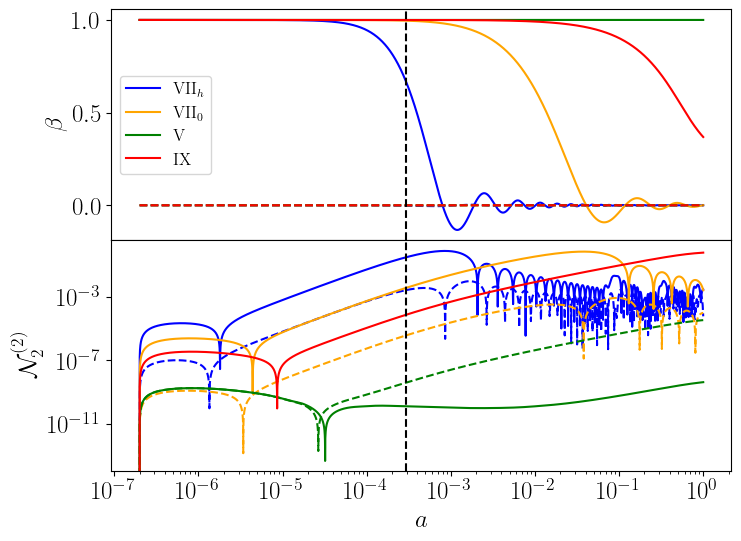

In [31]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
fig.subplots_adjust(hspace=0)

ax[0].plot(scale_factor, np.real(beta_viih_tensor), label=r'VII$_h$', color = 'blue')
ax[0].plot(scale_factor, np.imag(beta_viih_tensor), color = 'blue', linestyle='dashed')
ax[0].plot(scale_factor, np.real(beta_vii0_tensor), label=r'VII$_0$', color = 'orange')
ax[0].plot(scale_factor, np.imag(beta_vii0_tensor), color = 'orange', linestyle='dashed')
ax[0].plot(scale_factor, np.real(beta_v_tensor), label=r'V', color = 'green')
ax[0].plot(scale_factor, np.imag(beta_v_tensor), color = 'green', linestyle='dashed')
ax[0].plot(scale_factor, np.real(beta_ix_tensor), label=r'IX', color = 'red')
ax[0].plot(scale_factor, np.imag(beta_ix_tensor), color = 'red', linestyle='dashed')
ax[0].axvline(scale_factor_after_tc_viih[0], color='black', linestyle='dashed')
ax[0].set_xscale('log')
ax[0].set_ylabel(r'$\beta$')
#ax[0].set_xlabel(r'$a$')
# fig.legend(loc=7)
# fig.tight_layout()
# fig.subplots_adjust(right=0.75)
ax[0].legend()

ax[1].plot(scale_factor, np.abs(np.real(N_viih_tensor)), label=r'Bianchi VII$_h$ Real', color = 'blue')
ax[1].plot(scale_factor, np.abs(np.imag(N_viih_tensor)), label=r'Bianchi VII$_h$ Imag', color = 'blue', linestyle='dashed')
ax[1].plot(scale_factor, np.abs(np.real(N_vii0_tensor)), label=r'Bianchi VII$_0$ Real', color = 'orange')
ax[1].plot(scale_factor, np.abs(np.imag(N_vii0_tensor)), label=r'Bianchi VII$_0$ Imag', color = 'orange', linestyle='dashed')
ax[1].plot(scale_factor, np.abs(np.real(N_v_tensor)), label=r'Bianchi V Real', color = 'green')
ax[1].plot(scale_factor, np.abs(np.imag(N_v_tensor)), label=r'Bianchi V Imag', color = 'green', linestyle='dashed')
ax[1].plot(scale_factor, np.abs(np.real(N_ix_tensor)), label=r'Bianchi IX Real', color = 'red')
ax[1].plot(scale_factor, np.abs(np.imag(N_ix_tensor)), label=r'Bianchi IX Imag', color = 'red', linestyle='dashed')
ax[1].axvline(scale_factor_after_tc_viih[0], color='black', linestyle='dashed')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$a$')
ax[1].set_ylabel(r'$\mathcal{N}_2^{(2)}$')
#ax[1][0].set_title("Real")
#ax[1][0].legend()

#plt.savefig('beta_tensor2.pdf', bbox_inches='tight')


## Vector iso

In [32]:
Omega_K = 0.1
sqrth = 0.01
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [33]:
x.vector_solver()
scale_factor = x.atable
boltzmann_tc = x.vector_tc
boltzmann = x.nteb_vector
beta = -boltzmann[0]
N2_viih_vector = boltzmann[6]

beta_tc = -boltzmann_tc[0]
N2_tc = boltzmann_tc[6]
beta_viih_vector = np.hstack((beta_tc, beta))
N_viih_vector = np.hstack((N2_tc, N2_viih_vector))
index_end_tc = x.index_end_tightc
scale_factor_after_tc_viih = scale_factor[index_end_tc:]

In [34]:
Omega_K = 1e-5
sqrth = 1e-3
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [35]:
x.vector_solver()
scale_factor = x.atable
boltzmann_tc = x.vector_tc
boltzmann = x.nteb_vector
beta = -boltzmann[0]
N2_vii0_vector = boltzmann[6]

beta_tc = -boltzmann_tc[0]
N2_tc = boltzmann_tc[6]
beta_vii0_vector = np.hstack((beta_tc, beta))
N_vii0_vector = np.hstack((N2_tc, N2_vii0_vector))
index_end_tc = x.index_end_tightc
scale_factor_after_tc_vii0 = scale_factor[index_end_tc:]

In [36]:
Omega_K = 0.1
sqrth = 1e4
params = {'Omega_K' : Omega_K,
          'sqrth' : sqrth
          } 
x = Anilos(params) #intializing anilos

In [37]:
x.vector_solver()
scale_factor = x.atable
boltzmann_tc = x.vector_tc
boltzmann = x.nteb_vector
beta = -boltzmann[0]
N2_v_vector = boltzmann[6]

beta_tc = -boltzmann_tc[0]
N2_tc = boltzmann_tc[6]
beta_v_vector = np.hstack((beta_tc, beta))
N_v_vector = np.hstack((N2_tc, N2_v_vector))
index_end_tc = x.index_end_tightc
scale_factor_after_tc_v = scale_factor[index_end_tc:]

Text(0, 0.5, '$\\mathcal{N}_2^{(1)}$')

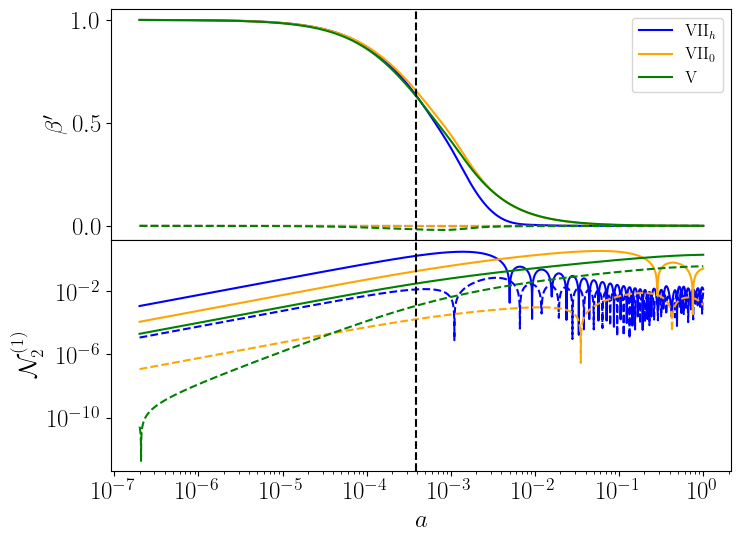

In [38]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
plt.rcParams.update({'font.size': 14})
fig.subplots_adjust(hspace=0)

ax[0].plot(scale_factor, np.real(beta_viih_vector), label=r'VII$_h$', color = 'blue')
ax[0].plot(scale_factor, np.imag(beta_viih_vector), color = 'blue', linestyle='dashed')
ax[0].plot(scale_factor, np.real(beta_vii0_vector), label=r'VII$_0$', color = 'orange')
ax[0].plot(scale_factor, np.imag(beta_vii0_vector), color = 'orange', linestyle='dashed')
ax[0].plot(scale_factor, np.real(beta_v_vector), label=r'V', color = 'green')
ax[0].plot(scale_factor, np.imag(beta_v_vector), color = 'green', linestyle='dashed')
ax[0].axvline(scale_factor_after_tc_viih[0], color='black', linestyle='dashed')
ax[0].set_xscale('log')
ax[0].set_ylabel(r'$\beta^\prime$')
#ax[0].set_xlabel(r'$a$')
ax[0].legend()

ax[1].plot(scale_factor, np.abs(np.real(N_viih_vector)), label=r'Bianchi VII$_h$ Real', color = 'blue')
ax[1].plot(scale_factor, np.abs(np.imag(N_viih_vector)), label=r'Bianchi VII$_h$ Imag', color = 'blue', linestyle='dashed')
ax[1].plot(scale_factor, np.abs(np.real(N_vii0_vector)), label=r'Bianchi VII$_0$ Real', color = 'orange')
ax[1].plot(scale_factor, np.abs(np.imag(N_vii0_vector)), label=r'Bianchi VII$_0$ Imag', color = 'orange', linestyle='dashed')
ax[1].plot(scale_factor, np.abs(np.real(N_v_vector)), label=r'Bianchi V Real', color = 'green')
ax[1].plot(scale_factor, np.abs(np.imag(N_v_vector)), label=r'Bianchi V Imag', color = 'green', linestyle='dashed')
ax[1].axvline(scale_factor_after_tc_viih[0], color='black', linestyle='dashed')
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$a$')
ax[1].set_ylabel(r'$\mathcal{N}_2^{(1)}$')
#ax[1][0].set_title("Real")
#ax[1][0].legend()

#plt.savefig('beta_vector2.pdf', bbox_inches='tight')


# Efficiency

In [39]:
l_vec = np.arange(10, 2500, 10)

In [40]:
# time_array_case1 = np.empty(l_vec.size)
# params = {'Omega_K' : 1e-5,
#           'sqrth' : 0.2 * np.sqrt(1e-5)
#          }
# for i, ell in enumerate (l_vec):
#     time_start = time.time()
#     y = Anilos(params)
#     y.tensor_solver()
#     y.vector_solver()
#     y.alm_tensor(ell, healpy = False)
#     y.alm_vector(ell, healpy = False)
#     time_end = time.time()
#     time_array_case1[i] = time_end - time_start

In [41]:
# np.save('time_case1.npy', time_array_case1)

In [42]:
# # Now AniCLASS
# k_output_tensor = 0.0011309490647693347
# cosmo = Class()
# params = {'Omega_k': 1e-5,

#           'hierarchy': 'tam',
#           'statistics': 'non_stochastic',
#           'non_stochastic_type': 'bianchi',

#           'output': 'tCl pCl',
#           'modes': 't v',
#           'multipole_normalization': 'observable',
#           'k_output_values': k_output_tensor,
#           #'l_max_tensors': ell_max,
#           #'l_max_vectors': ell_max,

#           'tight_coupling_trigger_tau_c_over_tau_h':0.005,
#           'start_small_omega_tau': 0.005,
#           'perturbations_sampling_stepsize' : 0.05,
#            'tol_perturbations_integration' : 1e-6,
#           'radiation_streaming_approximation': 3,
#           'hyper_x_min' : 1e-7,
#           'l_max_g': 30,
#           'l_max_pol_g': 30,
#           'l_max_ur': 30,
#           'l_max_g_ten': 30,
#           'l_max_pol_g_ten': 30,
#           'l_max_ur_ten': 30,
#           'l_max_g_vec': 30,
#           'l_max_pol_g_vec': 30,
#           'l_max_ur_vec': 30
#          }

In [43]:
# time_array_case2 = np.empty(l_vec.size)
# for i, ell in enumerate (l_vec):
#     cosmo = Class()
#     params['l_max_tensors'] = ell
#     params['l_max_vectors'] = ell
#     cosmo.set(params)
#     time_start = time.time()
#     cosmo.compute(['harmonic'])
#     time_end = time.time()
#     cosmo.struct_cleanup()
#     time_array_case2[i] = time_end - time_start

In [44]:
# np.save('time_case2.npy', time_array_case2)

In [45]:
time_array_case1 = np.load('time_case1.npy')
time_array_case2 = np.load('time_case2.npy')

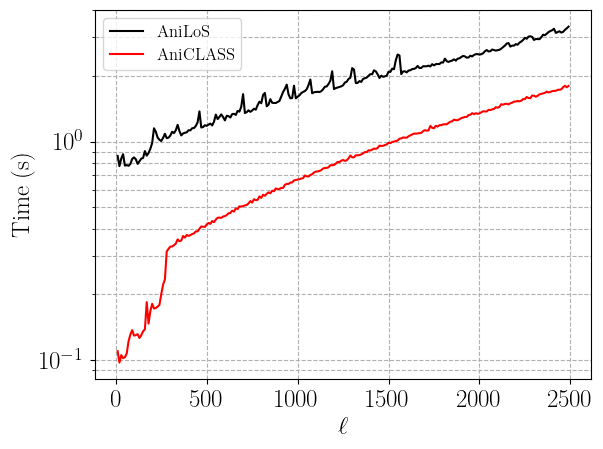

In [46]:
plt.plot(l_vec, time_array_case1, label = 'AniLoS', color = 'black')
plt.plot(l_vec, time_array_case2, label = 'AniCLASS', color = 'red')
plt.yscale('log')
plt.xlabel(r'$\ell$')
plt.ylabel('Time (s)')
plt.grid(True, which="both", ls = '--')
plt.legend()
#plt.savefig('time_total2.pdf', bbox_inches = 'tight')
plt.show()

# Maps

In [23]:
# Image settings
dpi = 200
cmap = 'planck'
cbar = False
figsz = (5, 2.5)

In [24]:
# Function to set the alms in the format expected by healpy (for class alms)
def alm_plot( alm_array, ell_max, type_mode = 'tensor'):
    len_alm = sum([l+1 for l in range(ell_max+1)]) #a_{l,-m} = (-1)^m a*_{lm}
    row = [0 for i in range(ell_max-1)]
    if type_mode == 'tensor':
        col = [i for i in range(2*ell_max+1,3*ell_max)]
    if type_mode == 'vector':
        col = [i for i in range(ell_max+ 2,2*ell_max + 1)]
    alm = coo_matrix((alm_array,
                        (row,col)
                        ),
                        shape=(1,len_alm),
                        dtype='complex'
                        )
    alm = np.array(alm.todense())[0]
    return alm

## Bianchi VII<sub>0<sub>

In [25]:
Omega_b = 0.04897
Omega_cdm = 0.2606
Omega_K = 1e-5
Omega_Lambda = 1 - Omega_b - Omega_cdm - Omega_K
k_output1 = 0.0022618981295386693
k_output2 = 0.0022618981295386693/2
k_output = str(k_output1)+','+str(k_output2)
lmax_tensors = 2500
lmax_vectors = 2500
z_reio = 10

In [26]:
# Now AniCLASS
cosmo = Class()
params = {'Omega_k': Omega_K,
          'Omega_b': Omega_b,
          'Omega_cdm': Omega_cdm,
          'Omega_Lambda': Omega_Lambda,
          'z_reio' : z_reio,

          'hierarchy': 'tam',
          'statistics': 'non_stochastic',
          'non_stochastic_type': 'bianchi',

          'output': 'tCl pCl',
          'modes': 't v',
          'non_stochastic_format': 'healpix_alm',
          'multipole_normalization': 'observable',
          'k_output_values': k_output,
          'l_max_tensors': lmax_tensors,
          'l_max_vectors': lmax_vectors,

          'tight_coupling_trigger_tau_c_over_tau_h':0.005,
          'start_small_omega_tau': 0.005,
          'perturbations_sampling_stepsize' : 0.01,
          'tol_perturbations_integration' : 1e-6,
          'radiation_streaming_approximation': 3,
          'hyper_x_min' : 1e-7,
          'l_max_g': 30,
          'l_max_pol_g': 30,
          'l_max_ur': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'l_max_g_vec': 30,
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,

          'background_verbose': 1
         }
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 1.130949e-03 corresponds to sqrth = 1.264911e-03 for tensor modes and 6.324555e-04 for vector modes
k_output_values[1] = 2.261898e-03 corresponds to sqrth = 6.324555e-04 for tensor modes and 3.162278e-04 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.774461 Gyr
 -> conformal age = 14157.521193 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3402.309622
    corresponding to conformal time = 112.836889 Mpc


In [27]:
alm_tensor = cosmo.alm(2500)['k_0']['t']
alm_vector = cosmo.alm(2500)['k_1']['v']

alm_tensorT = alm_tensor['T']
alm_tensorE = alm_tensor['E']
alm_tensorB = alm_tensor['B']

alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

alm_tensorT_plot = alm_plot(alm_tensorT, 2500, 'tensor')
alm_tensorE_plot = alm_plot(alm_tensorE, 2500, 'tensor')
alm_tensorB_plot = alm_plot(alm_tensorB, 2500, 'tensor')

alm_vectorT_plot = alm_plot(alm_vectorT, 2500, 'vector')
alm_vectorE_plot = alm_plot(alm_vectorE, 2500, 'vector')
alm_vectorB_plot = alm_plot(alm_vectorB, 2500, 'vector')

In [28]:
cosmo.struct_cleanup()

In [29]:
nside = 2 ** 7
map_tensorT = hp.sphtfunc.alm2map(alm_tensorT_plot, nside)
map_tensorE = hp.sphtfunc.alm2map(alm_tensorE_plot, nside)
map_tensorB = hp.sphtfunc.alm2map(alm_tensorB_plot, nside)

map_vectorT = hp.sphtfunc.alm2map(alm_vectorT_plot, nside)
map_vectorE = hp.sphtfunc.alm2map(alm_vectorE_plot, nside)
map_vectorB = hp.sphtfunc.alm2map(alm_vectorB_plot, nside)

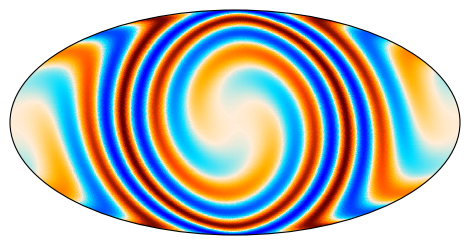

In [30]:
fig = plt.figure(figsize = figsz)
projview(map_tensorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_tensorT.pdf', bbox_inches = 'tight', dpi = dpi)

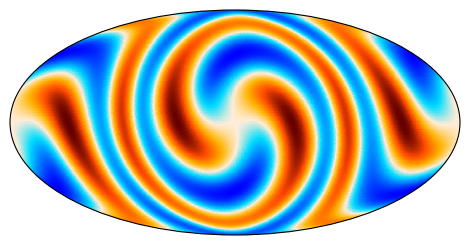

In [31]:
fig = plt.figure(figsize = figsz)
projview(map_tensorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_tensorE.pdf', bbox_inches = 'tight', dpi = dpi)

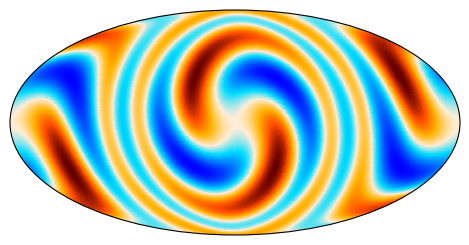

In [32]:
fig = plt.figure(figsize = figsz)
projview(map_tensorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_tensorB.pdf', bbox_inches = 'tight', dpi = dpi)

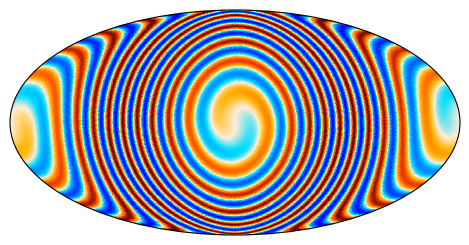

In [33]:
fig = plt.figure(figsize = figsz)
projview(map_vectorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_vector_isoT.pdf', bbox_inches = 'tight', dpi = dpi)

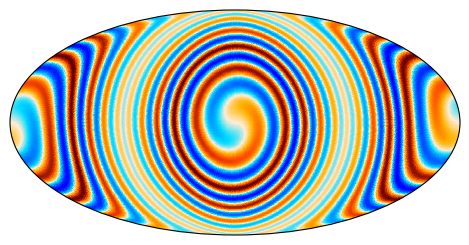

In [34]:
fig = plt.figure(figsize = figsz)
projview(map_vectorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_vector_isoE.pdf', bbox_inches = 'tight', dpi = dpi)

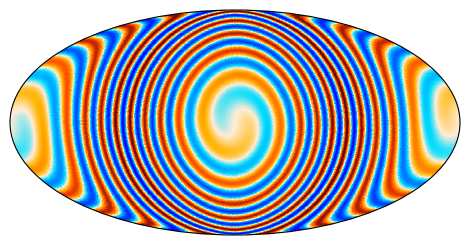

In [35]:
fig = plt.figure(figsize = figsz)
projview(map_vectorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_vector_isoB.pdf', bbox_inches = 'tight', dpi = dpi)

### Vector octopole initial conditions

In [36]:
params['ic_v'] = 'oct'
params['k_output_values'] = k_output2
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 1.130949e-03 corresponds to sqrth = 1.264911e-03 for tensor modes and 6.324555e-04 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.774461 Gyr
 -> conformal age = 14157.521193 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3402.309622
    corresponding to conformal time = 112.836889 Mpc


In [37]:
alm_vector = cosmo.alm(2500)['k_0']['v']

alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

In [38]:
alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

alm_vectorT_plot = alm_plot(alm_vectorT, 2500, 'vector')
alm_vectorE_plot = alm_plot(alm_vectorE, 2500, 'vector')
alm_vectorB_plot = alm_plot(alm_vectorB, 2500, 'vector')

In [39]:
cosmo.struct_cleanup()

In [40]:
nside = 2 ** 7

map_vectorT = hp.sphtfunc.alm2map(alm_vectorT_plot, nside)
map_vectorE = hp.sphtfunc.alm2map(alm_vectorE_plot, nside)
map_vectorB = hp.sphtfunc.alm2map(alm_vectorB_plot, nside)

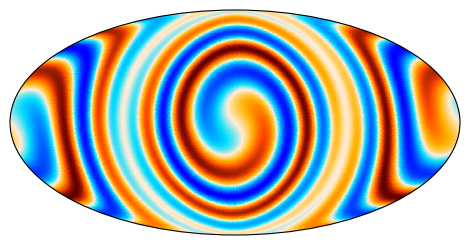

In [41]:
fig = plt.figure(figsize = figsz)
projview(map_vectorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_vector_octT.pdf', bbox_inches = 'tight', dpi = dpi)

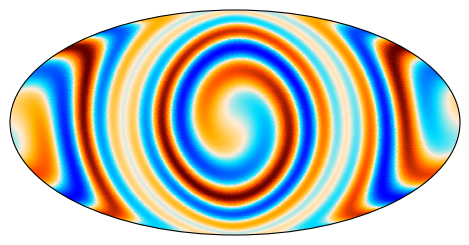

In [42]:
fig = plt.figure(figsize = figsz)
projview(map_vectorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_vector_octE.pdf', bbox_inches = 'tight', dpi = dpi)

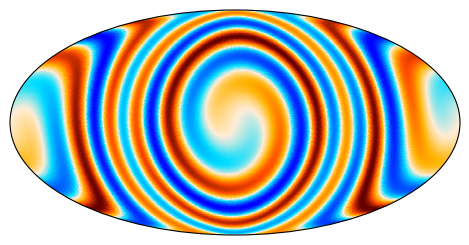

In [43]:
fig = plt.figure(figsize = figsz)
projview(map_vectorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_0_vector_octB.pdf', bbox_inches = 'tight', dpi = dpi)

## Bianchi VII<sub>h <sub>

In [44]:
Omega_m = 0.3
Omega_K = 0.1
Omega_Lambda = 1 - Omega_m - Omega_K
k_output1 = 0.00125
k_output2 = 0.00125 / 2
k_output = str(k_output1)+','+str(k_output2)
lmax_tensors = 2500
lmax_vectors = 2500
z_reio = 10

In [45]:
# Now AniCLASS
cosmo = Class()
params = {'Omega_k': Omega_K,
          'Omega_m': Omega_m,
          'Omega_Lambda': Omega_Lambda,
          'z_reio' : z_reio,

          'hierarchy': 'tam',
          'statistics': 'non_stochastic',
          'non_stochastic_type': 'bianchi',

          'output': 'tCl pCl',
          'modes': 't v',
          'non_stochastic_format': 'healpix_alm',
          'multipole_normalization': 'observable',
          'k_output_values': k_output,
          'l_max_tensors': lmax_tensors,
          'l_max_vectors': lmax_vectors,

          'tight_coupling_trigger_tau_c_over_tau_h':0.005,
          'start_small_omega_tau': 0.005,
          'perturbations_sampling_stepsize' : 0.01,
          'tol_perturbations_integration' : 1e-6,
          'radiation_streaming_approximation': 3,
          'hyper_x_min' : 1e-7,
          'l_max_g': 30,
          'l_max_pol_g': 30,
          'l_max_ur': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'l_max_g_vec': 30,
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,

          'background_verbose': 1
         }
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 6.250000e-04 corresponds to sqrth = 2.288880e-01 for tensor modes and 1.144440e-01 for vector modes
k_output_values[1] = 1.250000e-03 corresponds to sqrth = 1.144440e-01 for tensor modes and 5.722200e-02 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.478108 Gyr
 -> conformal age = 13999.322933 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3297.100235
    corresponding to conformal time = 116.435335 Mpc


In [46]:
alm_tensor = cosmo.alm(2500)['k_0']['t']
alm_vector = cosmo.alm(2500)['k_1']['v']

alm_tensorT = alm_tensor['T']
alm_tensorE = alm_tensor['E']
alm_tensorB = alm_tensor['B']

alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

alm_tensorT_plot = alm_plot(alm_tensorT, 2500, 'tensor')
alm_tensorE_plot = alm_plot(alm_tensorE, 2500, 'tensor')
alm_tensorB_plot = alm_plot(alm_tensorB, 2500, 'tensor')

alm_vectorT_plot = alm_plot(alm_vectorT, 2500, 'vector')
alm_vectorE_plot = alm_plot(alm_vectorE, 2500, 'vector')
alm_vectorB_plot = alm_plot(alm_vectorB, 2500, 'vector')

In [47]:
cosmo.struct_cleanup()

In [48]:
nside = 2 ** 7
map_tensorT = hp.sphtfunc.alm2map(alm_tensorT_plot, nside)
map_tensorE = hp.sphtfunc.alm2map(alm_tensorE_plot, nside)
map_tensorB = hp.sphtfunc.alm2map(alm_tensorB_plot, nside)

map_vectorT = hp.sphtfunc.alm2map(alm_vectorT_plot, nside)
map_vectorE = hp.sphtfunc.alm2map(alm_vectorE_plot, nside)
map_vectorB = hp.sphtfunc.alm2map(alm_vectorB_plot, nside)

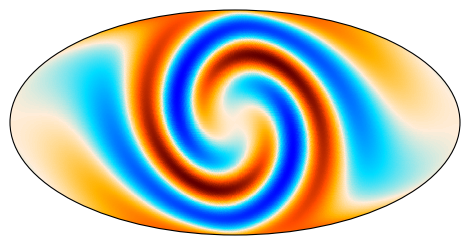

In [49]:
fig = plt.figure(figsize = figsz)
projview(map_tensorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_tensorT.pdf', bbox_inches = 'tight', dpi = dpi)

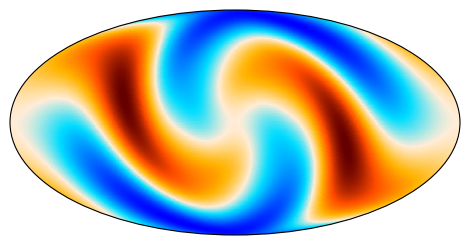

In [50]:
fig = plt.figure(figsize = figsz)
projview(map_tensorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_tensorE.pdf', bbox_inches = 'tight', dpi = dpi)

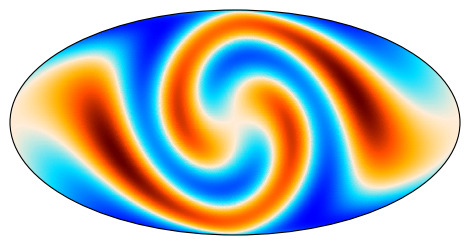

In [51]:
fig = plt.figure(figsize = figsz)
projview(map_tensorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_tensorB.pdf', bbox_inches = 'tight', dpi = dpi)

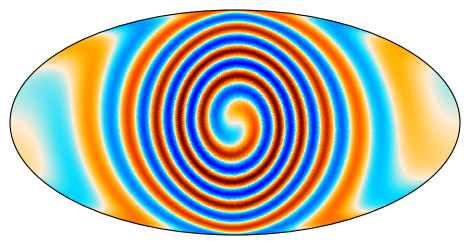

In [52]:
fig = plt.figure(figsize = figsz)
projview(map_vectorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_vector_isoT.pdf', bbox_inches = 'tight', dpi = dpi)

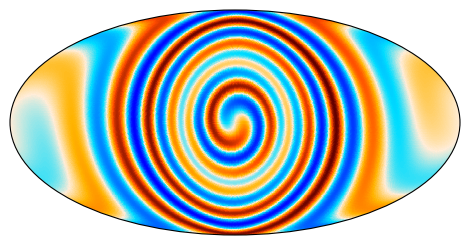

In [53]:
fig = plt.figure(figsize = figsz)
projview(map_vectorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_vector_isoE.pdf', bbox_inches = 'tight', dpi = dpi)

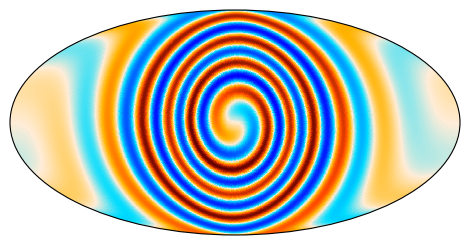

In [54]:
fig = plt.figure(figsize = figsz)
projview(map_vectorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_vector_isoB.pdf', bbox_inches = 'tight', dpi = dpi)

### Vector octopole initial conditions

In [55]:
params['ic_v'] = 'oct'
params['k_output_values'] = k_output2
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 6.250000e-04 corresponds to sqrth = 2.288880e-01 for tensor modes and 1.144440e-01 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.478108 Gyr
 -> conformal age = 13999.322933 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3297.100235
    corresponding to conformal time = 116.435335 Mpc


In [56]:
alm_vector = cosmo.alm(2500)['k_0']['v']

alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

In [57]:
alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

alm_vectorT_plot = alm_plot(alm_vectorT, 2500, 'vector')
alm_vectorE_plot = alm_plot(alm_vectorE, 2500, 'vector')
alm_vectorB_plot = alm_plot(alm_vectorB, 2500, 'vector')

In [58]:
cosmo.struct_cleanup()

In [59]:
nside = 2 ** 7

map_vectorT = hp.sphtfunc.alm2map(alm_vectorT_plot, nside)
map_vectorE = hp.sphtfunc.alm2map(alm_vectorE_plot, nside)
map_vectorB = hp.sphtfunc.alm2map(alm_vectorB_plot, nside)

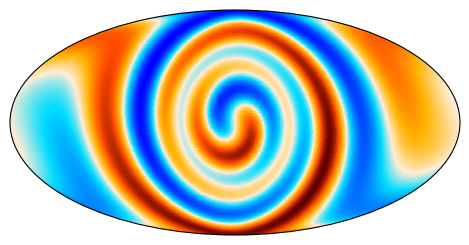

In [60]:
fig = plt.figure(figsize = figsz)
projview(map_vectorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_vector_octT.pdf', bbox_inches = 'tight', dpi = dpi)

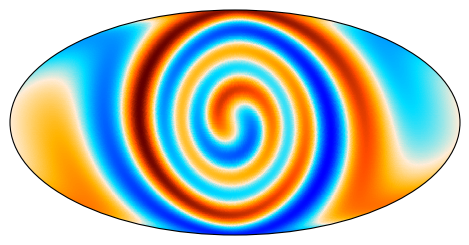

In [61]:
fig = plt.figure(figsize = figsz)
projview(map_vectorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_vector_octE.pdf', bbox_inches = 'tight', dpi = dpi)

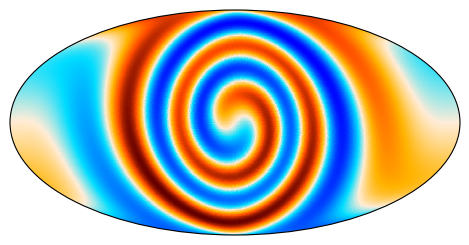

In [62]:
fig = plt.figure(figsize = figsz)
projview(map_vectorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiVII_h_vector_octB.pdf', bbox_inches = 'tight', dpi = dpi)

## Bianchi V

In [63]:
Omega_m = 0.3
Omega_K = 0.1
Omega_Lambda = 1 - Omega_m - Omega_K
k_output1 = 4.5237962590773387e-10
k_output2 = 4.5237962590773387e-10/2
k_output = str(k_output1)+','+str(k_output2)
lmax_tensors = 2500
lmax_vectors = 2500
z_reio = 10

In [64]:
# Now AniCLASS
cosmo = Class()
params = {'Omega_k': Omega_K,
          'Omega_m': Omega_m,
          'Omega_Lambda': Omega_Lambda,
          'z_reio' : z_reio,

          'hierarchy': 'tam',
          'statistics': 'non_stochastic',
          'non_stochastic_type': 'bianchi',

          'output': 'tCl pCl',
          'modes': 't v',
          'non_stochastic_format': 'healpix_alm',
          'multipole_normalization': 'observable',
          'k_output_values': k_output,
          'l_max_tensors': lmax_tensors,
          'l_max_vectors': lmax_vectors,

          'tight_coupling_trigger_tau_c_over_tau_h':0.005,
          'start_small_omega_tau': 0.005,
          'perturbations_sampling_stepsize' : 0.01,
          'tol_perturbations_integration' : 1e-6,
          'radiation_streaming_approximation': 3,
          'hyper_x_min' : 1e-7,
          'l_max_g': 30,
          'l_max_pol_g': 30,
          'l_max_ur': 30,
          'l_max_g_ten': 30,
          'l_max_pol_g_ten': 30,
          'l_max_ur_ten': 30,
          'l_max_g_vec': 30,
          'l_max_pol_g_vec': 30,
          'l_max_ur_vec': 30,

          'background_verbose': 1
         }
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 2.261898e-10 corresponds to sqrth = 6.324555e+05 for tensor modes and 3.162278e+05 for vector modes
k_output_values[1] = 4.523796e-10 corresponds to sqrth = 3.162278e+05 for tensor modes and 1.581139e+05 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.478108 Gyr
 -> conformal age = 13999.322933 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3297.100235
    corresponding to conformal time = 116.435335 Mpc


In [65]:
alm_tensor = cosmo.alm(2500)['k_0']['t']
alm_vector = cosmo.alm(2500)['k_1']['v']

alm_tensorT = alm_tensor['T']
alm_tensorE = alm_tensor['E']
alm_tensorB = alm_tensor['B']

alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

alm_tensorT_plot = alm_plot(alm_tensorT, 2500, 'tensor')
alm_tensorE_plot = alm_plot(alm_tensorE, 2500, 'tensor')
alm_tensorB_plot = alm_plot(alm_tensorB, 2500, 'tensor')

alm_vectorT_plot = alm_plot(alm_vectorT, 2500, 'vector')
alm_vectorE_plot = alm_plot(alm_vectorE, 2500, 'vector')
alm_vectorB_plot = alm_plot(alm_vectorB, 2500, 'vector')

In [66]:
cosmo.struct_cleanup()

In [67]:
nside = 2 ** 7
map_tensorT = hp.sphtfunc.alm2map(alm_tensorT_plot, nside)
map_tensorE = hp.sphtfunc.alm2map(alm_tensorE_plot, nside)
map_tensorB = hp.sphtfunc.alm2map(alm_tensorB_plot, nside)

map_vectorT = hp.sphtfunc.alm2map(alm_vectorT_plot, nside)
map_vectorE = hp.sphtfunc.alm2map(alm_vectorE_plot, nside)
map_vectorB = hp.sphtfunc.alm2map(alm_vectorB_plot, nside)

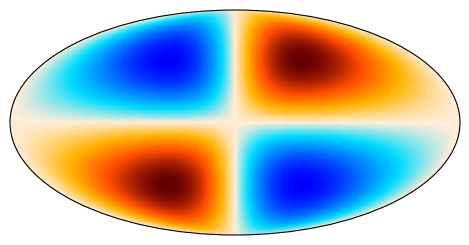

In [68]:
fig = plt.figure(figsize = figsz)
projview(map_tensorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_tensorT.pdf', bbox_inches = 'tight', dpi = dpi)

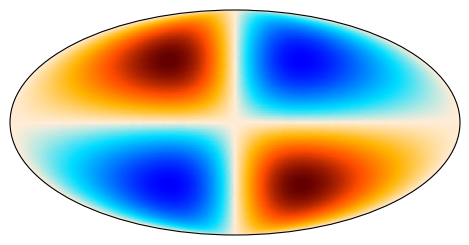

In [69]:
fig = plt.figure(figsize = figsz)
projview(map_tensorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_tensorE.pdf', bbox_inches = 'tight', dpi = dpi)

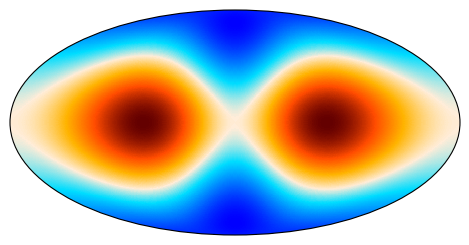

In [70]:
fig = plt.figure(figsize = figsz)
projview(map_tensorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_tensorB.pdf', bbox_inches = 'tight', dpi = dpi)

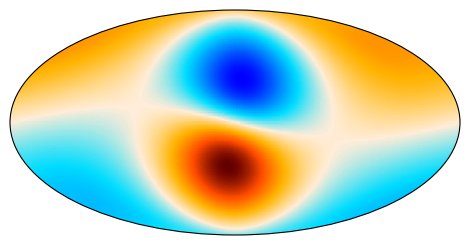

In [71]:
fig = plt.figure(figsize = figsz)
projview(map_vectorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_vector_isoT.pdf', bbox_inches = 'tight', dpi = dpi)

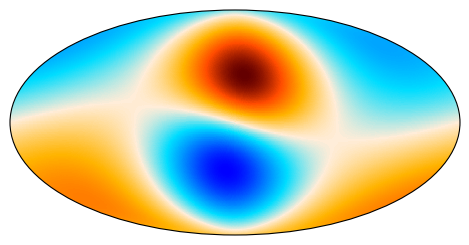

In [72]:
fig = plt.figure(figsize = figsz)
projview(map_vectorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_vector_isoE.pdf', bbox_inches = 'tight', dpi = dpi)

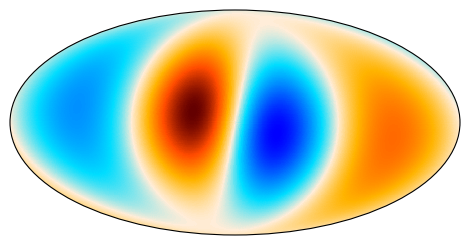

In [73]:
fig = plt.figure(figsize = figsz)
projview(map_vectorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_vector_isoB.pdf', bbox_inches = 'tight', dpi = dpi)

### Vector octopole initial conditions

In [74]:
params['ic_v'] = 'oct'
params['k_output_values'] = k_output2
cosmo.set(params)
cosmo.compute(['harmonic'])

k_output_values[0] = 2.261898e-10 corresponds to sqrth = 6.324555e+05 for tensor modes and 3.162278e+05 for vector modes
Running CLASS version v3.2.5
!! WARNING !!! CLASS has been compiled with complex valued perturbations, sources and transfer functions.
Computing background
 -> age = 13.478108 Gyr
 -> conformal age = 13999.322933 Mpc
 -> N_eff = 3.044 (summed over all species that are non-relativistic at early times) 
 -> radiation/matter equality at z = 3297.100235
    corresponding to conformal time = 116.435335 Mpc


In [75]:
alm_vector = cosmo.alm(2500)['k_0']['v']

alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

In [76]:
alm_vectorT = alm_vector['T']
alm_vectorE = alm_vector['E']
alm_vectorB = alm_vector['B']

alm_vectorT_plot = alm_plot(alm_vectorT, 2500, 'vector')
alm_vectorE_plot = alm_plot(alm_vectorE, 2500, 'vector')
alm_vectorB_plot = alm_plot(alm_vectorB, 2500, 'vector')

In [77]:
cosmo.struct_cleanup()

In [78]:
nside = 2 ** 7

map_vectorT = hp.sphtfunc.alm2map(alm_vectorT_plot, nside)
map_vectorE = hp.sphtfunc.alm2map(alm_vectorE_plot, nside)
map_vectorB = hp.sphtfunc.alm2map(alm_vectorB_plot, nside)

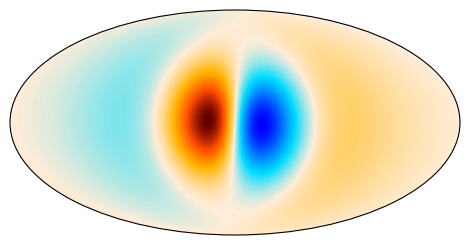

In [79]:
fig = plt.figure(figsize = figsz)
projview(map_vectorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_vector_octT.pdf', bbox_inches = 'tight', dpi = dpi)

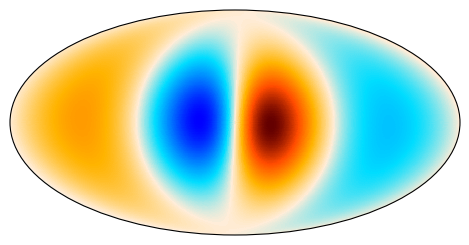

In [80]:
fig = plt.figure(figsize = figsz)
projview(map_vectorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_vector_octE.pdf', bbox_inches = 'tight', dpi = dpi)

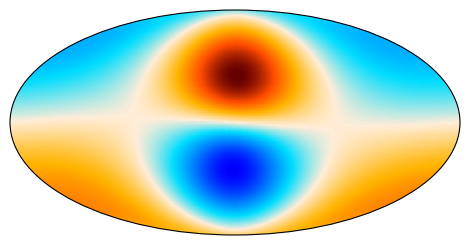

In [81]:
fig = plt.figure(figsize = figsz)
projview(map_vectorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiV_vector_octB.pdf', bbox_inches = 'tight', dpi = dpi)

## Bianchi IX

In [82]:
Omega_m = 0.3
Omega_K = -0.1
Omega_Lambda = 1 - Omega_m - Omega_K
lmax_tensors = 2500
z_reio = 10

In [83]:
cosmo = Class()
params = {'Omega_k': Omega_K,
          'Omega_m': Omega_m,
          'Omega_Lambda': Omega_Lambda,
          'hierarchy': 'tam',
          'radiation_streaming_approximation': 3,
          'statistics': 'non_stochastic',
          'non_stochastic_type': 'bianchi',
          'output': 'tCl pCl',
          'modes': 't',
          'l_max_tensors': lmax_tensors,
          'z_reio' : z_reio
         }
cosmo.set(params)
cosmo.compute(['harmonic'])

Setting the k_value to 1.752059e-04 as this is fixed to this unique value for Bianchi IX type non stochastic perturbation.


In [84]:
alm_tensor = cosmo.alm(2500)['k_0']['t']

In [85]:
alm_tensorT = alm_tensor['T']
alm_tensorE = alm_tensor['E']
alm_tensorB = alm_tensor['B']

alm_tensorT_plot = alm_plot(alm_tensorT, 2500, 'tensor')
alm_tensorE_plot = alm_plot(alm_tensorE, 2500, 'tensor')
alm_tensorB_plot = alm_plot(alm_tensorB, 2500, 'tensor')

In [86]:
cosmo.struct_cleanup()

In [87]:
nside = 2 ** 7
map_tensorT = hp.sphtfunc.alm2map(alm_tensorT_plot, nside)
map_tensorE = hp.sphtfunc.alm2map(alm_tensorE_plot, nside)
map_tensorB = hp.sphtfunc.alm2map(alm_tensorB_plot, nside)

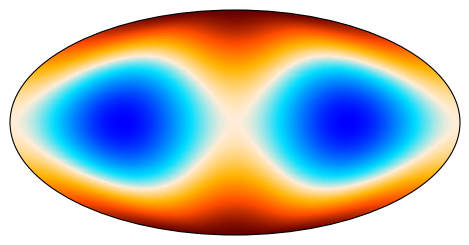

In [88]:
fig = plt.figure(figsize = figsz)
projview(map_tensorT, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiIX_tensorT.pdf', bbox_inches = 'tight', dpi = dpi)

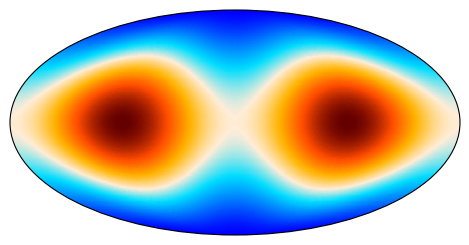

In [89]:
fig = plt.figure(figsize = figsz)
projview(map_tensorE, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiIX_tensorE.pdf', bbox_inches = 'tight', dpi = dpi)

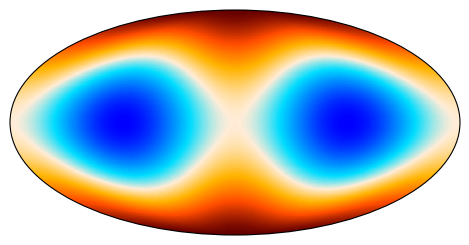

In [90]:
fig = plt.figure(figsize = figsz)
projview(map_tensorB, rot = (0, 90, 0), cmap = cmap, cbar = cbar, hold = True)
#plt.savefig('BianchiIX_tensorB.pdf', bbox_inches = 'tight', dpi = dpi)